# Progetto Finale — Modulo 3: Clustering non supervisionato

**Obiettivo:** esplorare due metodologie distinte (**DBSCAN** e **Elbow Method** tramite Inertia/WCSS) per determinare il numero ottimale di cluster $K$ su un dataset non etichettato. Successivamente si applica **K-Means** con il $K$ identificato.

Dataset: **Iris**, ignorando le etichette di classe originali.

## 0. Import delle librerie

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

## 1. Data Exploration & Preprocessing

- **Caricamento e Analisi:** caricare il dataset e fornire un'analisi descrittiva iniziale (es. `df.describe()`).
- **Standardizzazione:** applicare la standardizzazione alle feature ($X$) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

## 2. Stima di $K$ con DBSCAN

Eseguire l'algoritmo DBSCAN iterativamente per analizzare la struttura dei dati basata sulla densità.

**Parametri di iterazione:**
- `min_samples = 5`
- `eps` $\in [0.35, 0.45, 0.55]$

**Metriche da determinare per ogni esecuzione:**
- Il numero di cluster $K$ identificati.
- Il numero di punti rumorosi (label -1).

**Selezione:** individuare il numero di cluster $K$ più plausibile tra i risultati ottenuti.

In [4]:
eps_value = [0.35, 0.45, 0.55]
for value in eps_value:
    db = DBSCAN(eps=value, min_samples=5)
    labels = db.fit_predict(X_scaled)
    rumore = (labels == -1).sum()
    cluster = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={value} -> cluster: {cluster}, rumore: {rumore}")

eps=0.35 -> cluster: 4, rumore: 104
eps=0.45 -> cluster: 3, rumore: 54
eps=0.55 -> cluster: 2, rumore: 29


## 3. Stima di $K$ con Elbow Method

Utilizzare K-Means per identificare il $K$ ottimale analizzando l'inerzia (WCSS: Within Cluster Sum of Squares).

**Configurazione:**
- Algoritmo: K-Means.
- Range di $K$: da 1 a 10.

**Visualizzazione:**
- Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e $K$ sull'asse X).
- Identificazione del "punto di gomito" (dove la curva si piega).
- Inserimento di un asse verticale in corrispondenza del valore $x = K$ scelto.

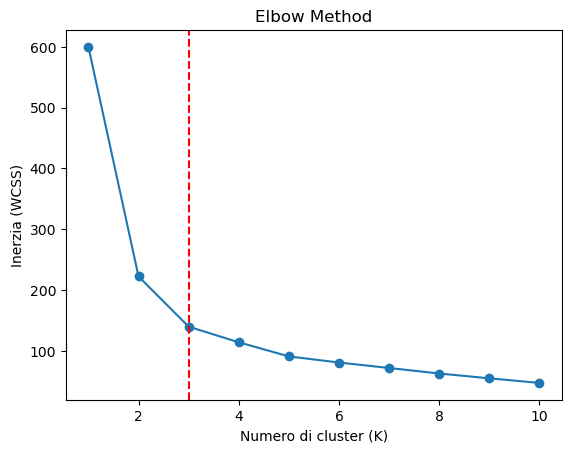

In [5]:
inerzie = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=21, n_init=10)
    km.fit(X_scaled)
    inerzie.append(km.inertia_)

plt.plot(range(1, 11), inerzie, marker='o')
plt.xlabel('Numero di cluster (K)')
plt.axvline(x=3, color='red', linestyle='--', label='K scelto = 3')
plt.ylabel('Inerzia (WCSS)')
plt.title('Elbow Method')
plt.show()

## 4. Applicazione Finale & Visualizzazione

- **Clusterizzazione definitiva:** stabilire il $K$ finale e applicare K-Means sul dataset standardizzato.
- **Valutazione:** calcolare il **Silhouette Score** per valutare la coesione interna e la separazione dei cluster.
- **Visualizzazione risultati:**
  - Plot dei dati proiettati in 2D (usando le prime due feature).
  - Rappresentazione dei centroidi dei cluster.

Silhouette Score: 0.460


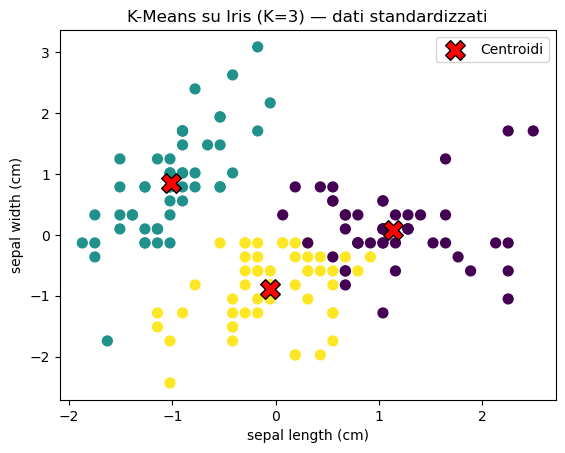

In [11]:
kmeans = KMeans(n_clusters=3, random_state=21, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels_kmeans)
print(f"Silhouette Score: {score:.3f}")

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, edgecolors='black', label='Centroidi')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('K-Means su Iris (K=3) — dati standardizzati')
plt.legend()
plt.show()